In [1]:
# ==============================
# Library Imports and Setup
# ==============================
import mediapipe as mp          # For hand, pose, and holistic landmark detection
import tensorflow as tf         # For model building
import numpy as np              # For numerical computations
import cv2                      # For video capture and image processing
import os                       # For file and folder operations
import sklearn                  # For dataset splitting and metrics
from matplotlib import pyplot as plt  # For visualizations

# Print versions for reproducibility
print("TensorFlow:", tf.__version__)
print("Mediapipe:", mp.__version__)
print("NumPy:", np.__version__)

# Mediapipe Holistic model setup
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
print("Holistic loaded successfully")

TensorFlow: 2.10.1
Mediapipe: 0.10.10
NumPy: 1.23.5
Holistic loaded successfully


In [2]:
def mediapipe_detection(image: np.ndarray, model) -> tuple[np.ndarray, mp_holistic.Holistic]:
    """
    Process an image frame using Mediapipe Holistic model.

    Args:
        image (np.ndarray): BGR image from OpenCV
        model: Mediapipe Holistic model instance

    Returns:
        image (np.ndarray): Processed image (BGR)
        results: Mediapipe results object with landmarks
    """
    try:
        # Convert color and make image read-only for processing
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image_rgb.flags.writeable = False

        results = model.process(image_rgb)  # Predict landmarks

        # Convert back to BGR for OpenCV display
        image_rgb.flags.writeable = True
        image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

        return image_bgr, results
    except Exception as e:
        print("Error in Mediapipe detection:", e)
        return image, None

In [3]:
def draw_landmarks(image, results):

    if results is None:
        return image

    if results.face_landmarks:
        mp_drawing.draw_landmarks(image,results.face_landmarks,mp.solutions.face_mesh.FACEMESH_TESSELATION)

    if results.pose_landmarks:
        mp_drawing.draw_landmarks(image,results.pose_landmarks,mp_holistic.POSE_CONNECTIONS)

    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image,results.left_hand_landmarks,mp_holistic.HAND_CONNECTIONS)

    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(image,results.right_hand_landmarks,mp_holistic.HAND_CONNECTIONS)

    return image

In [4]:
def draw_styled_landmarks(image, results):
    """
    Draws landmarks for face, pose, and hands with emphasis on hands for mudra clarity.
    Face and pose are slightly dimmed to reduce clutter.
    """

    if results is None:
        return image

    # Draw face connections (lighter)
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.face_landmarks,
            mp.solutions.face_mesh.FACEMESH_TESSELATION,
            mp_drawing.DrawingSpec(color=(150,150,150), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(200,200,200), thickness=1, circle_radius=1)
        )

    # Draw pose connections (dimmed)
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.pose_landmarks,
            mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(100,100,100), thickness=2, circle_radius=3),
            mp_drawing.DrawingSpec(color=(120,120,120), thickness=2, circle_radius=2)
        )

    # Draw left hand (bold)
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.left_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,0,255), thickness=3, circle_radius=5),
            mp_drawing.DrawingSpec(color=(0,0,200), thickness=2, circle_radius=3)
        )

    # Draw right hand (bold)
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image,
            results.right_hand_landmarks,
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,0), thickness=3, circle_radius=5),
            mp_drawing.DrawingSpec(color=(0,200,0), thickness=2, circle_radius=3)
        )

    return image

In [5]:
import time
cap = cv2.VideoCapture(0)

try:
    with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5
    ) as holistic:

        prev_time = 0  # for FPS calculation

        while True:   # 🔥 DO NOT use cap.isOpened()
            ret, frame = cap.read()
            if not ret:
                print("Failed to grab frame")
                break

            # Optional: Resize for consistent processing speed
            frame = cv2.resize(frame, (640, 480))

            # Mediapipe detection
            image, results = mediapipe_detection(frame, holistic)

            # Draw landmarks and get updated image
            if results is not None:
                image = draw_styled_landmarks(image, results)

            # Optional: display FPS
            curr_time = time.time()
            fps = 1 / (curr_time - prev_time) if prev_time != 0 else 0
            prev_time = curr_time
            cv2.putText(image, f'FPS: {int(fps)}', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

            # Show image
            cv2.imshow('OpenCV Feed', image)

            # Exit on 'q'
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Exiting loop...")
                break

except KeyboardInterrupt:
    print("Manually stopped")

finally:
    print("Releasing camera...")
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)   # 🔥 VERY IMPORTANT in Jupyter

Exiting loop...
Releasing camera...


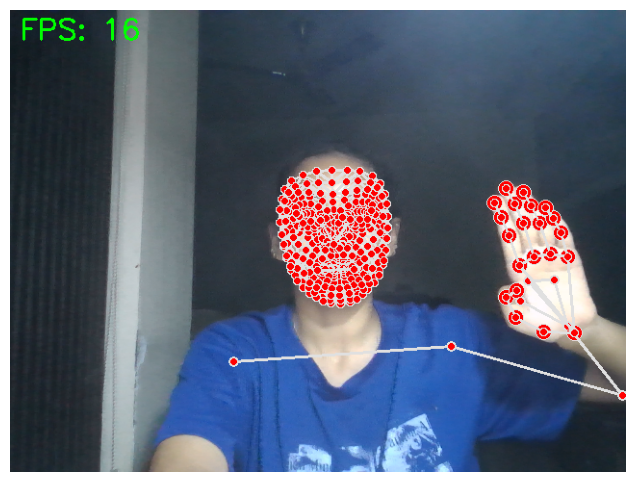

In [6]:
# Draw the basic landmarks (optional, for debugging)
if results is not None:
    image = draw_landmarks(image, results)

# Convert BGR to RGB for matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [7]:
if results is not None and results.left_hand_landmarks:
    print(len(results.left_hand_landmarks.landmark))
else:
    print("Left hand not detected")

21


In [8]:
pose = (
    np.array([[res.x, res.y, res.z, res.visibility] 
              for res in results.pose_landmarks.landmark])
    if results is not None and results.pose_landmarks 
    else np.zeros((33, 4))
)

In [9]:
# Pose keypoints (33 * 4 = 132)
pose = (
    np.array([[res.x, res.y, res.z, res.visibility] 
              for res in results.pose_landmarks.landmark]).flatten()
    if results is not None and results.pose_landmarks else np.zeros(33*4)
)

# Left hand keypoints (21 * 3 = 63)
lh = (
    np.array([[res.x, res.y, res.z] 
              for res in results.left_hand_landmarks.landmark]).flatten()
    if results is not None and results.left_hand_landmarks else np.zeros(21*3)
)

# Right hand keypoints (21 * 3 = 63)
rh = (
    np.array([[res.x, res.y, res.z] 
              for res in results.right_hand_landmarks.landmark]).flatten()
    if results is not None and results.right_hand_landmarks else np.zeros(21*3)
)

In [10]:
def extract_keypoints(results):

    # Pose landmarks (33 * 4 = 132)
    pose = (
        np.array([[res.x, res.y, res.z, res.visibility] 
                  for res in results.pose_landmarks.landmark]).flatten()
        if results is not None and results.pose_landmarks else np.zeros(33*4)
    )

    # Left hand landmarks (21 * 3 = 63)
    lh = (
        np.array([[res.x, res.y, res.z] 
                  for res in results.left_hand_landmarks.landmark]).flatten()
        if results is not None and results.left_hand_landmarks else np.zeros(21*3)
    )

    # Right hand landmarks (21 * 3 = 63)
    rh = (
        np.array([[res.x, res.y, res.z] 
                  for res in results.right_hand_landmarks.landmark]).flatten()
        if results is not None and results.right_hand_landmarks else np.zeros(21*3)
    )

    # Concatenate
    return np.concatenate([pose, lh, rh])

In [11]:
if results is not None:
    result_test = extract_keypoints(results)

    print("Keypoints shape:", result_test.shape)
    print(result_test[:10], "...")

    np.save('keypoints_0.npy', result_test)
    print("Keypoints saved as 'keypoints_0.npy'")

    loaded_test = np.load('keypoints_0.npy')
    print("Loaded keypoints shape:", loaded_test.shape)

Keypoints shape: (258,)
[ 0.5255295   0.50667387 -0.90723562  0.99997932  0.55177408  0.45317683
 -0.83108461  0.99996954  0.56789732  0.45298633] ...
Keypoints saved as 'keypoints_0.npy'
Loaded keypoints shape: (258,)


In [12]:
import os

FINALMUDRA = r'C:\Users\seeth\FINALMUDRA'
DATA_PATH = os.path.join(FINALMUDRA, 'MP_Data')

if not os.path.exists(DATA_PATH):
    os.makedirs(DATA_PATH)
    print(f"Dataset folder created at '{DATA_PATH}'")
else:
    print(f"Dataset folder already exists at '{DATA_PATH}'")
    

Dataset folder already exists at 'C:\Users\seeth\FINALMUDRA\MP_Data'


In [13]:
import os

actions = [
    'pathakam_sword', 'pathakam_blessing', 'pathakam_sweep',
    'kartarimukha_eyes', 'kartarimukha_creeper', 'kartarimukha_next',
    'alapadmam_flower', 'alapadmam_birth', 'alapadmam_fruit',
    'katakamukham_necklace', 'katakamukham_smell',
    'ardhachandra_half_moon', 'ardhachandra_think', 'ardhachandra_waist',
    'shikaram_Recollection', 'shikaram_pillar', 'shikaram_hug',
    'mrighasrisham_deer', 'mrighasrisham_house', 'mrighasrisham_fear'
]
sequence_length = 30

In [14]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# ------------------------------
# Hierarchical label maps
# ------------------------------

# Level 1: Mudra labels
mudras = sorted(list(set(action.split('_', 1)[0] for action in actions)))
mudra_label_map = {mudra: num for num, mudra in enumerate(mudras)}
print("Mudra label map:", mudra_label_map)

# Level 2: Meaning labels per mudra
meaning_label_map = {}
for action in actions:
    mudra, meaning = action.split('_', 1)
    if mudra not in meaning_label_map:
        meaning_label_map[mudra] = []
    meaning_label_map[mudra].append(meaning)

# Convert meaning names to integer labels for each mudra
for mudra in meaning_label_map:
    mudra_meanings = sorted(list(set(meaning_label_map[mudra])))
    meaning_label_map[mudra] = {meaning: num for num, meaning in enumerate(mudra_meanings)}

print("Meaning label map per mudra:", meaning_label_map)

Mudra label map: {'alapadmam': 0, 'ardhachandra': 1, 'kartarimukha': 2, 'katakamukham': 3, 'mrighasrisham': 4, 'pathakam': 5, 'shikaram': 6}
Meaning label map per mudra: {'pathakam': {'blessing': 0, 'sweep': 1, 'sword': 2}, 'kartarimukha': {'creeper': 0, 'eyes': 1, 'next': 2}, 'alapadmam': {'birth': 0, 'flower': 1, 'fruit': 2}, 'katakamukham': {'necklace': 0, 'smell': 1}, 'ardhachandra': {'half_moon': 0, 'think': 1, 'waist': 2}, 'shikaram': {'Recollection': 0, 'hug': 1, 'pillar': 2}, 'mrighasrisham': {'deer': 0, 'fear': 1, 'house': 2}}


In [15]:
sequences = []
mudra_labels = []
meaning_labels = []

for action in actions:

    print("Loading:", action)

    mudra_name, meaning_name = action.split('_', 1)
    action_path = os.path.join(DATA_PATH, mudra_name, meaning_name)

    if not os.path.exists(action_path):
        print("Missing folder:", action_path)
        continue

    for sequence in sorted(os.listdir(action_path)):

        window = []
        sequence_path = os.path.join(action_path, sequence)

        if not os.path.isdir(sequence_path):
            continue

        for frame_num in range(sequence_length):

            npy_path = os.path.join(sequence_path, f"{frame_num}.npy")

            if not os.path.exists(npy_path):
                break

            try:
                res = np.load(npy_path)
            except:
                break

            window.append(res)

        if len(window) == sequence_length:

            sequences.append(window)

            mudra_labels.append(mudra_label_map[mudra_name])
            meaning_labels.append(meaning_label_map[mudra_name][meaning_name])

print("Dataset loading complete!")

Loading: pathakam_sword
Loading: pathakam_blessing
Loading: pathakam_sweep
Loading: kartarimukha_eyes
Loading: kartarimukha_creeper
Loading: kartarimukha_next
Loading: alapadmam_flower
Loading: alapadmam_birth
Loading: alapadmam_fruit
Loading: katakamukham_necklace
Loading: katakamukham_smell
Loading: ardhachandra_half_moon
Loading: ardhachandra_think
Loading: ardhachandra_waist
Loading: shikaram_Recollection
Loading: shikaram_pillar
Loading: shikaram_hug
Loading: mrighasrisham_deer
Loading: mrighasrisham_house
Loading: mrighasrisham_fear
Dataset loading complete!


In [16]:
# Convert to numpy arrays
X = np.array(sequences)
mudra_labels = np.array(mudra_labels)
meaning_labels = np.array(meaning_labels)

# One-hot encode outputs
y_mudra = to_categorical(mudra_labels).astype(int)
y_meaning = to_categorical(meaning_labels).astype(int)

# Train-test split
X_train, X_test, y_mudra_train, y_mudra_test, y_meaning_train, y_meaning_test = train_test_split(
    X,
    y_mudra,
    y_meaning,
    test_size=0.15,
    random_state=42,
    stratify=mudra_labels
)

print("X_train shape:", X_train.shape)
print("Mudra output shape:", y_mudra_train.shape)
print("Meaning output shape:", y_meaning_train.shape)

X_train shape: (2040, 30, 258)
Mudra output shape: (2040, 7)
Meaning output shape: (2040, 3)


In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard
import datetime

# Create a unique log directory for TensorBoard
log_dir = os.path.join("Logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
os.makedirs(log_dir, exist_ok=True)

# TensorBoard callback
tb_callback = TensorBoard(log_dir=log_dir)

In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, BatchNormalization

# Input layer
inputs = Input(shape=(sequence_length, X.shape[2]))

# Shared BiLSTM backbone
x = Bidirectional(LSTM(128, return_sequences=True, activation='tanh'))(inputs)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(128, return_sequences=False, activation='tanh'))(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = BatchNormalization()(x)

# Output 1: Mudra classification
mudra_output = Dense(len(mudras), activation='softmax', name='mudra_output')(x)

# Output 2: Meaning classification
meaning_output = Dense(y_meaning.shape[1], activation='softmax', name='meaning_output')(x)

# Final model
model = Model(inputs=inputs, outputs=[mudra_output, meaning_output])

In [19]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss={
        'mudra_output': 'categorical_crossentropy',
        'meaning_output': 'categorical_crossentropy'
    },
    metrics={
        'mudra_output': 'accuracy',
        'meaning_output': 'accuracy'
    }
)

history = model.fit(
    X_train,
    {
        'mudra_output': y_mudra_train,
        'meaning_output': y_meaning_train
    },
    validation_data=(
        X_test,
        {
            'mudra_output': y_mudra_test,
            'meaning_output': y_meaning_test
        }
    ),
    epochs=150,
    batch_size=16,
    callbacks=[tb_callback]
)

model.summary()

Epoch 1/150
128/128 [==============================] - 12s 55ms/step - loss: 2.5800 - mudra_output_loss: 1.6502 - meaning_output_loss: 0.9298 - mudra_output_accuracy: 0.3985 - meaning_output_accuracy: 0.5853 - val_loss: 1.3078 - val_mudra_output_loss: 0.9436 - val_meaning_output_loss: 0.3642 - val_mudra_output_accuracy: 0.6806 - val_meaning_output_accuracy: 0.8778
Epoch 2/150
128/128 [==============================] - 7s 56ms/step - loss: 1.0451 - mudra_output_loss: 0.7002 - meaning_output_loss: 0.3448 - mudra_output_accuracy: 0.7554 - meaning_output_accuracy: 0.8755 - val_loss: 0.4590 - val_mudra_output_loss: 0.3235 - val_meaning_output_loss: 0.1354 - val_mudra_output_accuracy: 0.8944 - val_meaning_output_accuracy: 0.9639
Epoch 3/150
128/128 [==============================] - 9s 67ms/step - loss: 0.6089 - mudra_output_loss: 0.4060 - meaning_output_loss: 0.2029 - mudra_output_accuracy: 0.8828 - meaning_output_accuracy: 0.9309 - val_loss: 0.3698 - val_mudra_output_loss: 0.1957 - val_mea

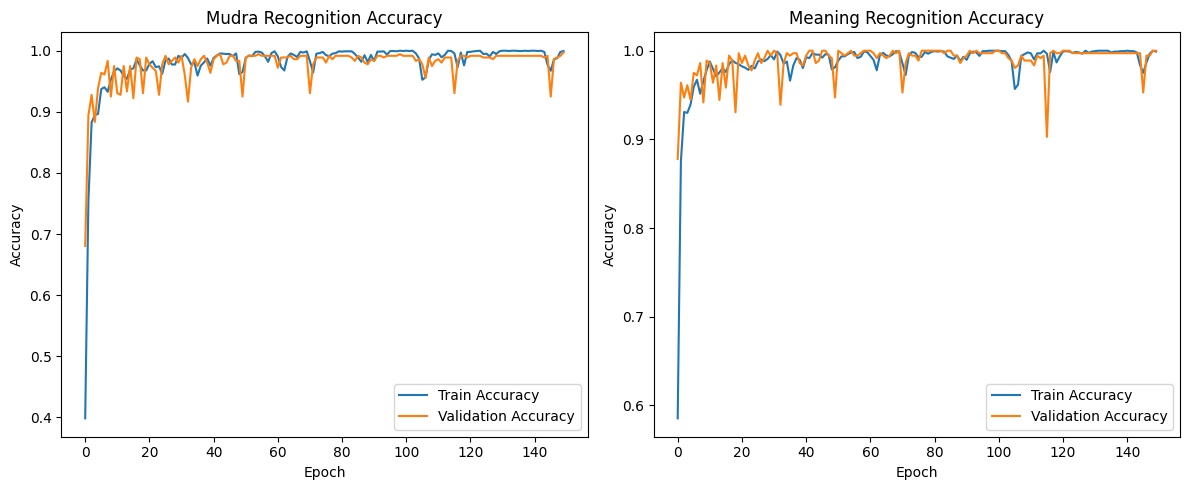

In [56]:
# ==============================
# Training Curves
# ==============================

plt.figure(figsize=(12,5))

# -------- Mudra Accuracy --------
plt.subplot(1,2,1)
plt.plot(history.history['mudra_output_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_mudra_output_accuracy'], label='Validation Accuracy')
plt.title("Mudra Recognition Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# -------- Meaning Accuracy --------
plt.subplot(1,2,2)
plt.plot(history.history['meaning_output_accuracy'], label='Train Accuracy')
plt.plot(history.history['val_meaning_output_accuracy'], label='Validation Accuracy')
plt.title("Meaning Recognition Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

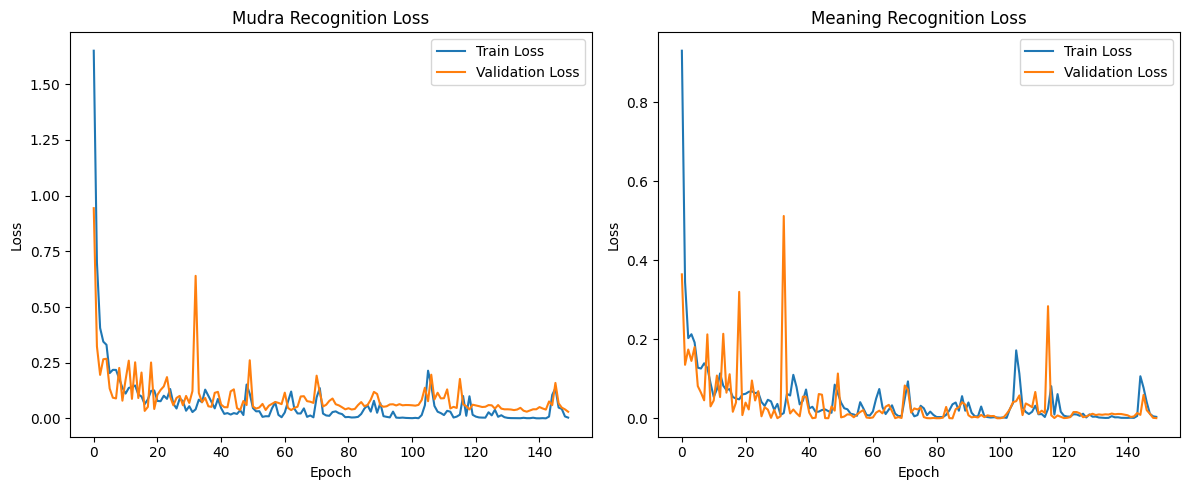

In [57]:
plt.figure(figsize=(12,5))

# -------- Mudra Loss --------
plt.subplot(1,2,1)
plt.plot(history.history['mudra_output_loss'], label='Train Loss')
plt.plot(history.history['val_mudra_output_loss'], label='Validation Loss')
plt.title("Mudra Recognition Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# -------- Meaning Loss --------
plt.subplot(1,2,2)
plt.plot(history.history['meaning_output_loss'], label='Train Loss')
plt.plot(history.history['val_meaning_output_loss'], label='Validation Loss')
plt.title("Meaning Recognition Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [58]:
# ==============================
# Predict on Test Set
# ==============================
yhat_mudra, yhat_meaning = model.predict(X_test)

# Convert predictions to label indices
yhat_mudra_labels = np.argmax(yhat_mudra, axis=1)
yhat_meaning_labels = np.argmax(yhat_meaning, axis=1)

# Convert true labels to indices
ytrue_mudra = np.argmax(y_mudra_test, axis=1)
ytrue_meaning = np.argmax(y_meaning_test, axis=1)

# ==============================
# Create inverse mudra label map
# ==============================
inv_mudra_map = {v: k for k, v in mudra_label_map.items()}

# ==============================
# Compare the first test sample
# ==============================

# Predicted and true mudra indices
pred_mudra_idx = yhat_mudra_labels[0]
true_mudra_idx = ytrue_mudra[0]

# Convert indices to mudra names
pred_mudra = inv_mudra_map[pred_mudra_idx]
true_mudra = inv_mudra_map[true_mudra_idx]

# ==============================
# Decode meanings
# ==============================

# Meaning map for predicted mudra
inv_pred_meaning_map = {v: k for k, v in meaning_label_map[pred_mudra].items()}

# Meaning map for true mudra
inv_true_meaning_map = {v: k for k, v in meaning_label_map[true_mudra].items()}

# Predicted and true meaning indices
pred_meaning_idx = yhat_meaning_labels[0]
true_meaning_idx = ytrue_meaning[0]

# Convert indices to meaning text
pred_meaning = inv_pred_meaning_map.get(pred_meaning_idx, "Unknown")
true_meaning = inv_true_meaning_map.get(true_meaning_idx, "Unknown")

# ==============================
# Print Results
# ==============================

print("Predicted Mudra:", pred_mudra)
print("True Mudra:", true_mudra)

print("Predicted Meaning:", pred_meaning)
print("True Meaning:", true_meaning)

12/12 [==============================] - 2s 118ms/step
Predicted Mudra: pathakam
True Mudra: pathakam
Predicted Meaning: sword
True Meaning: sword


In [21]:
import tensorflow as tf

# -----------------------------
# Save model
# -----------------------------
model_version = 1
model_filename = f'action_v{model_version}.keras'

model.save(model_filename)
print(f"Model saved successfully as {model_filename}")

# -----------------------------
# Clear model from memory
# -----------------------------
del model

# -----------------------------
# Load the saved model
# -----------------------------
from tensorflow.keras.models import load_model

# Load for inference
model = load_model(model_filename, compile=False)
print(f"Model {model_filename} loaded successfully and ready for predictions")

# -----------------------------
# Recompile if further training is needed
# -----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss={
        'mudra_output': 'categorical_crossentropy',
        'meaning_output': 'categorical_crossentropy'
    },
    metrics={
        'mudra_output': 'categorical_accuracy',
        'meaning_output': 'categorical_accuracy'
    }
)

Model saved successfully as action_v1.keras
Model action_v1.keras loaded successfully and ready for predictions


In [23]:
from sklearn.metrics import accuracy_score

mudra_accuracy = accuracy_score(ytrue_mudra, yhat_mudra_labels)
meaning_accuracy = accuracy_score(ytrue_meaning, yhat_meaning_labels)

print("\nOverall Mudra Accuracy:", mudra_accuracy)
print("Overall Meaning Accuracy:", meaning_accuracy)


Overall Mudra Accuracy: 0.9972222222222222
Overall Meaning Accuracy: 1.0


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [44]:
print("===== MUDRA CLASSIFICATION METRICS =====")

mudra_accuracy = accuracy_score(ytrue_mudra, yhat_mudra_labels)
mudra_precision = precision_score(ytrue_mudra, yhat_mudra_labels, average='weighted')
mudra_recall = recall_score(ytrue_mudra, yhat_mudra_labels, average='weighted')
mudra_f1 = f1_score(ytrue_mudra, yhat_mudra_labels, average='weighted')

print("Accuracy :", mudra_accuracy)
print("Precision:", mudra_precision)
print("Recall   :", mudra_recall)
print("F1 Score :", mudra_f1)

print("===== MUDRA CLASSIFICATION REPORT =====")

print(
    classification_report(
        ytrue_mudra,
        yhat_mudra_labels,
        target_names=mudras
    )
)

===== MUDRA CLASSIFICATION METRICS =====
Accuracy : 0.9972222222222222
Precision: 0.9972727272727272
Recall   : 0.9972222222222222
F1 Score : 0.9972219840521307
===== MUDRA CLASSIFICATION REPORT =====
               precision    recall  f1-score   support

    alapadmam       1.00      1.00      1.00        54
 ardhachandra       1.00      1.00      1.00        54
 kartarimukha       1.00      0.98      0.99        54
 katakamukham       1.00      1.00      1.00        36
mrighasrisham       1.00      1.00      1.00        54
     pathakam       0.98      1.00      0.99        54
     shikaram       1.00      1.00      1.00        54

     accuracy                           1.00       360
    macro avg       1.00      1.00      1.00       360
 weighted avg       1.00      1.00      1.00       360



In [45]:
print("===== MEANING CLASSIFICATION METRICS =====")

meaning_accuracy = accuracy_score(ytrue_meaning, yhat_meaning_labels)
meaning_precision = precision_score(ytrue_meaning, yhat_meaning_labels, average='weighted')
meaning_recall = recall_score(ytrue_meaning, yhat_meaning_labels, average='weighted')
meaning_f1 = f1_score(ytrue_meaning, yhat_meaning_labels, average='weighted')

print("Accuracy :", meaning_accuracy)
print("Precision:", meaning_precision)
print("Recall   :", meaning_recall)
print("F1 Score :", meaning_f1)

print("===== MEANING CLASSIFICATION REPORT =====")

# Create a flat list of all meanings
all_meanings = []
for mudra in meaning_label_map:
    for meaning in meaning_label_map[mudra]:
        all_meanings.append(meaning)

all_meanings = sorted(list(set(all_meanings)))

print(
    classification_report(
        ytrue_meaning,
        yhat_meaning_labels
    )
)

===== MEANING CLASSIFICATION METRICS =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
===== MEANING CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       1.00      1.00      1.00       131
           2       1.00      1.00      1.00       118

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



In [50]:
print("======================================")
print("PER-CLASS MUDRA PERFORMANCE")
print("======================================")

print(classification_report(
    ytrue_mudra,
    yhat_mudra_labels,
    target_names=mudras,
    digits=4
))

PER-CLASS MUDRA PERFORMANCE
               precision    recall  f1-score   support

    alapadmam     1.0000    1.0000    1.0000        54
 ardhachandra     1.0000    1.0000    1.0000        54
 kartarimukha     1.0000    0.9815    0.9907        54
 katakamukham     1.0000    1.0000    1.0000        36
mrighasrisham     1.0000    1.0000    1.0000        54
     pathakam     0.9818    1.0000    0.9908        54
     shikaram     1.0000    1.0000    1.0000        54

     accuracy                         0.9972       360
    macro avg     0.9974    0.9974    0.9974       360
 weighted avg     0.9973    0.9972    0.9972       360



In [51]:
print("======================================")
print("PER-CLASS MEANING PERFORMANCE")
print("======================================")

print(classification_report(
    ytrue_meaning,
    yhat_meaning_labels,
    digits=4
))

PER-CLASS MEANING PERFORMANCE
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       111
           1     1.0000    1.0000    1.0000       131
           2     1.0000    1.0000    1.0000       118

    accuracy                         1.0000       360
   macro avg     1.0000    1.0000    1.0000       360
weighted avg     1.0000    1.0000    1.0000       360



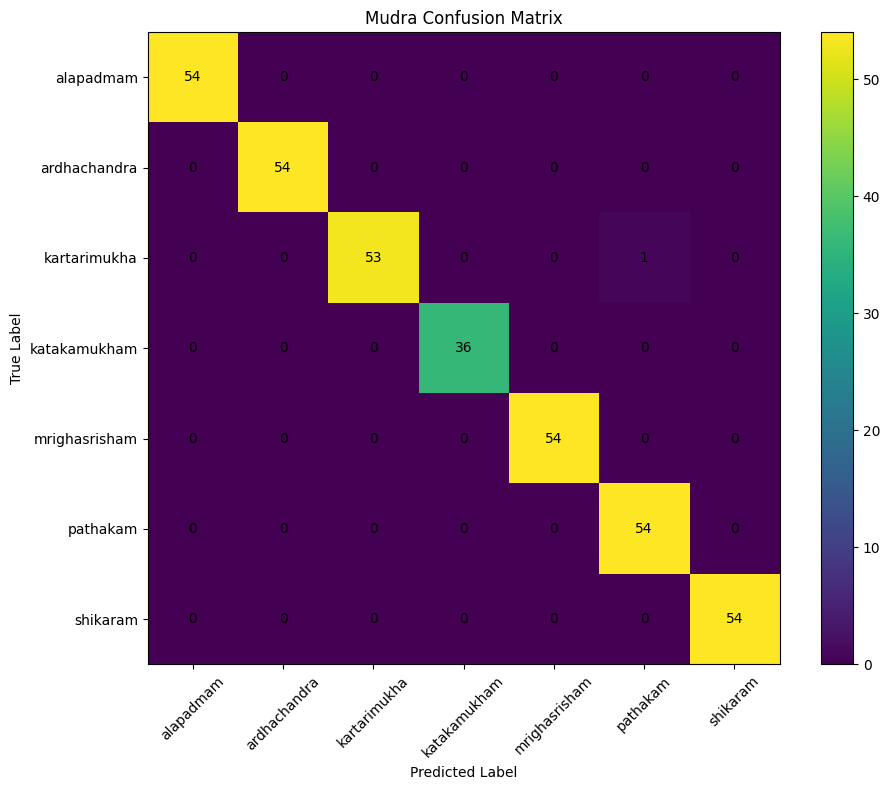

In [53]:
cm_mudra = confusion_matrix(ytrue_mudra, yhat_mudra_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm_mudra)
plt.title("Mudra Confusion Matrix")
plt.colorbar()

ticks = np.arange(len(mudras))
plt.xticks(ticks, mudras, rotation=45)
plt.yticks(ticks, mudras)

# Add numbers inside cells
for i in range(cm_mudra.shape[0]):
    for j in range(cm_mudra.shape[1]):
        plt.text(j, i, cm_mudra[i, j],
                 ha="center", va="center",
                 color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

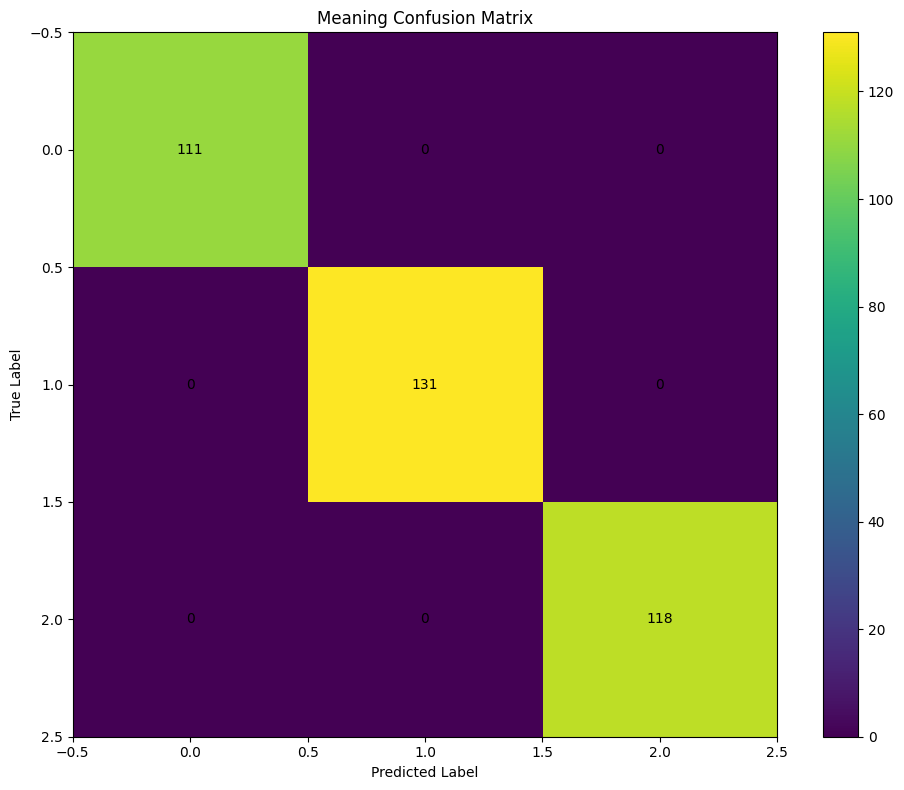

In [54]:
cm_meaning = confusion_matrix(ytrue_meaning, yhat_meaning_labels)

plt.figure(figsize=(10,8))
plt.imshow(cm_meaning)
plt.title("Meaning Confusion Matrix")
plt.colorbar()

# Add numbers inside cells
for i in range(cm_meaning.shape[0]):
    for j in range(cm_meaning.shape[1]):
        plt.text(j, i, cm_meaning[i, j],
                 ha="center", va="center",
                 color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [55]:
print("======================================")
print("FINAL PERFORMANCE SUMMARY")
print("======================================")

print("Mudra Recognition")
print(f"Accuracy : {mudra_accuracy:.4f}")
print(f"Precision: {mudra_precision:.4f}")
print(f"Recall   : {mudra_recall:.4f}")
print(f"F1 Score : {mudra_f1:.4f}")

print("\nMeaning Recognition")
print(f"Accuracy : {meaning_accuracy:.4f}")
print(f"Precision: {meaning_precision:.4f}")
print(f"Recall   : {meaning_recall:.4f}")
print(f"F1 Score : {meaning_f1:.4f}")

FINAL PERFORMANCE SUMMARY
Mudra Recognition
Accuracy : 0.9972
Precision: 0.9974
Recall   : 0.9974
F1 Score : 0.9974

Meaning Recognition
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [24]:
def prob_viz_hierarchical(yhat_mudra, yhat_meaning, mudras_list, meaning_label_map, input_frame, colors=None):
    """
    Visualizes mudra probabilities + meaning probabilities for predicted mudra.
    """

    if colors is None:
        colors = [
            (245,117,16),(117,245,16),(16,117,245),
            (255,0,0),(0,255,0),(0,0,255),
            (255,255,0),(255,0,255),(0,255,255)
        ]

    output_frame = input_frame.copy()
    
    # --- Mudra bars ---
    mudra_probs = yhat_mudra.flatten()

    for num, prob in enumerate(mudra_probs):
        color = colors[num % len(colors)]
        top_left = (0, 60 + num*40)
        bottom_right = (int(prob*200), 90 + num*40)

        cv2.rectangle(output_frame, top_left, bottom_right, color, -1)

        cv2.putText(
            output_frame,
            f"{mudras_list[num]}: {prob*100:.1f}%",
            (5, 85 + num*40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,255,255),
            2,
            cv2.LINE_AA
        )

    # --- Meaning bars for predicted mudra ---
    pred_mudra_idx = np.argmax(mudra_probs)
    pred_mudra_name = mudras_list[pred_mudra_idx]

    meaning_map = meaning_label_map[pred_mudra_name]
    meaning_probs = yhat_meaning.flatten()

    for i, (meaning, idx) in enumerate(meaning_map.items()):

        prob = meaning_probs[idx]
        color = colors[(i + len(mudras_list)) % len(colors)]

        top_left = (220, 60 + i*40)
        bottom_right = (220 + int(prob*200), 90 + i*40)

        cv2.rectangle(output_frame, top_left, bottom_right, color, -1)

        cv2.putText(
            output_frame,
            f"{meaning}: {prob*100:.1f}%",
            (225, 85 + i*40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,255,255),
            2,
            cv2.LINE_AA
        )

    return output_frame

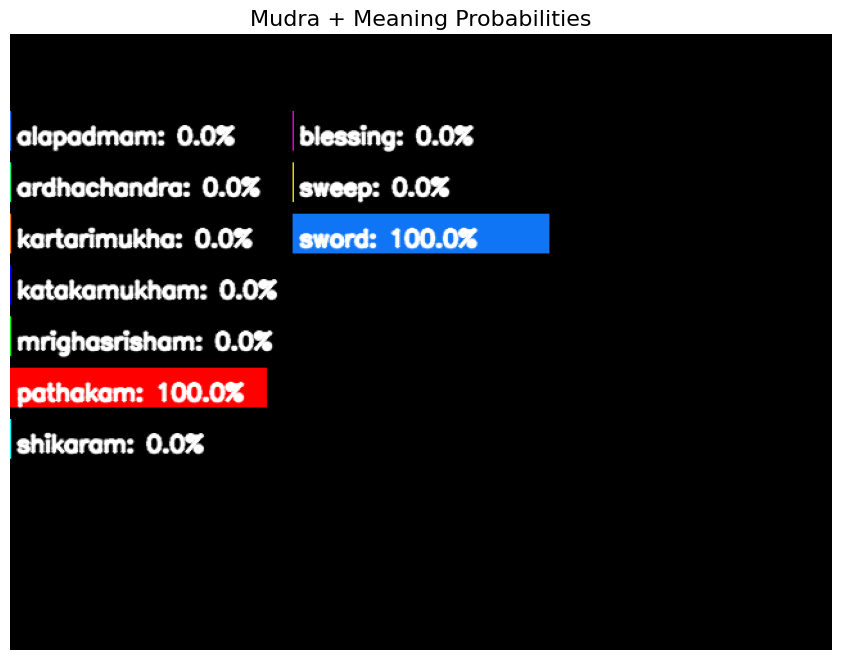

In [25]:
import matplotlib.pyplot as plt
import cv2

# Default colors if not defined earlier
colors = [
    (245,117,16),(117,245,16),(16,117,245),
    (255,0,0),(0,255,0),(0,0,255),
    (255,255,0),(255,0,255),(0,255,255)
]

# yhat_mudra[0], yhat_meaning[0] are predictions for this frame/sequence

viz_frame = prob_viz_hierarchical(
    yhat_mudra=yhat_mudra[0],
    yhat_meaning=yhat_meaning[0],
    mudras_list=mudras,
    meaning_label_map=meaning_label_map,
    input_frame = np.zeros((480,640,3), dtype=np.uint8),
    colors=colors
)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(viz_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Mudra + Meaning Probabilities", fontsize=16)
plt.show()

In [64]:
sequence = []
sentence = []
predictions_mudra = []
predictions_meaning = []

threshold = 0.7
sequence_length = 30   # MUST match training

with mp_holistic.Holistic(
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5) as holistic:

    cap = cv2.VideoCapture(0)

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (640, 480))

        # Mediapipe detection
        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(image, results)

        # Extract keypoints
        keypoints = extract_keypoints(results)

        sequence.append(keypoints)
        sequence = sequence[-sequence_length:]

        if len(sequence) == sequence_length:

            # Model prediction
            res_mudra, res_meaning = model.predict(
                np.expand_dims(sequence, axis=0),
                verbose=0
            )

            predicted_mudra_idx = np.argmax(res_mudra[0])
            predicted_meaning_idx = np.argmax(res_meaning[0])

            predicted_mudra = inv_mudra_map[predicted_mudra_idx]

            # Meaning map for predicted mudra
            inv_meaning_map = {
                v: k for k, v in meaning_label_map[predicted_mudra].items()
            }

            predicted_meaning = inv_meaning_map.get(predicted_meaning_idx, "Unknown")

            # Store predictions for stability
            predictions_mudra.append(predicted_mudra_idx)
            predictions_meaning.append(predicted_meaning_idx)

            recent_mudra = predictions_mudra[-10:]
            recent_meaning = predictions_meaning[-10:]

            # Stability check
            if (
                len(recent_mudra) == 10
                and np.all(np.array(recent_mudra) == predicted_mudra_idx)
                and len(recent_meaning) == 10
                and np.all(np.array(recent_meaning) == predicted_meaning_idx)
            ):
                phrase = predicted_mudra + "_" + predicted_meaning

                if not sentence or phrase != sentence[-1]:
                    if (
                        res_mudra[0][predicted_mudra_idx] > threshold
                        and res_meaning[0][predicted_meaning_idx] > threshold
                    ):
                        sentence.append(phrase)

            if len(sentence) > 5:
                sentence = sentence[-5:]

            # Probability visualization
            image = prob_viz_hierarchical(
                res_mudra[0],
                res_meaning[0],
                mudras,
                meaning_label_map,
                image,
                colors
            )

        # Display recognized sequence
        cv2.rectangle(image, (0, 0), (640, 40), (245,117,16), -1)

        cv2.putText(
            image,
            ' '.join(sentence),
            (10,30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
            cv2.LINE_AA
        )

        cv2.imshow('OpenCV Feed', image)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()